In [1]:
# !pip install yfinance
# !pip install --upgrade yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

## Data Collection

In [3]:
# now = datetime.now()

# start = datetime(now.year-10,now.month,now.day)
# end = now
# ticker = 'AAPL'
# df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
# #df = yf.download(ticker,start,end)

import yfinance as yf
from datetime import datetime

now = datetime.now()

start = datetime(now.year - 10, now.month, now.day)
end = now

ticker = "AAPL"

df = df = yf.download(
    ticker,
    start=start,
    end=end,
    progress=False,
    threads=False,
    auto_adjust=True
)

df.head()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400
2016-03-15,23.685331,23.821219,23.520000,23.544913,160270800
2016-03-16,24.000137,24.077140,23.687593,23.692124,153214000
2016-03-17,23.961628,24.113369,23.771384,23.898212,137682800
2016-03-18,23.988813,24.120173,23.823484,24.083935,176820800


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400
2016-03-15,23.685331,23.821219,23.520000,23.544913,160270800
2016-03-16,24.000137,24.077140,23.687593,23.692124,153214000
2016-03-17,23.961628,24.113369,23.771384,23.898212,137682800
2016-03-18,23.988813,24.120173,23.823484,24.083935,176820800


## Data Exploration and visualization

In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
df.shape

(2514, 5)

In [7]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03
mean,118.777408,119.961689,117.482256,118.672278,9.889508e+07
std,74.895943,75.623296,74.108835,74.839895,5.581947e+07
min,20.584818,20.887866,20.386581,20.507342,1.791060e+07
25%,43.526838,43.915960,43.153411,43.476478,5.991080e+07
50%,124.333332,126.075523,123.121332,124.707571,8.687350e+07
75%,175.075882,176.646217,173.242424,174.695459,1.207034e+08
max,285.922455,288.350192,283.035157,285.932471,4.584084e+08


In [9]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [10]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400
2016-03-15,23.685331,23.821219,23.520000,23.544913,160270800
2016-03-16,24.000137,24.077140,23.687593,23.692124,153214000
2016-03-17,23.961628,24.113369,23.771384,23.898212,137682800
2016-03-18,23.988813,24.120173,23.823484,24.083935,176820800


In [11]:
df = df.reset_index()

In [12]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400
1,2016-03-15,23.685331,23.821219,23.520000,23.544913,160270800
2,2016-03-16,24.000137,24.077140,23.687593,23.692124,153214000
3,2016-03-17,23.961628,24.113369,23.771384,23.898212,137682800
4,2016-03-18,23.988813,24.120173,23.823484,24.083935,176820800


Text(0, 0.5, 'Close Price')

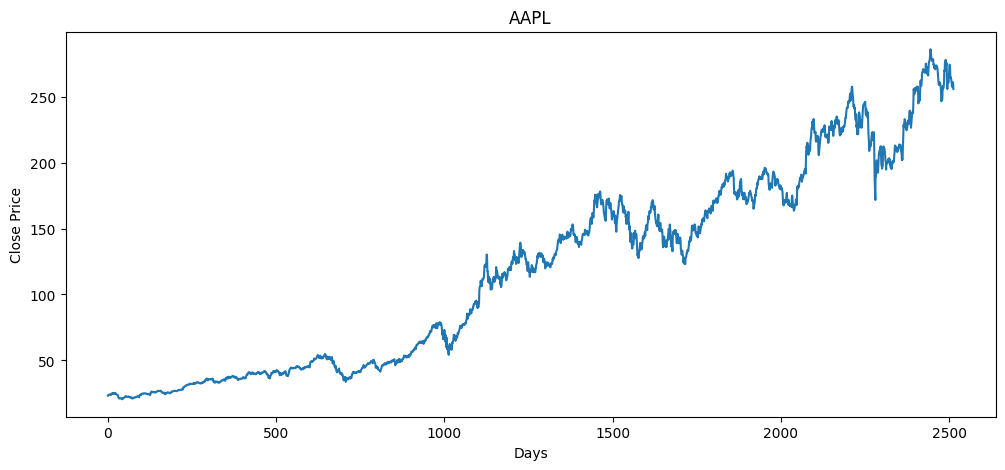

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price')

## Feature Engineering

In [14]:
temp_df = [10, 20 ,30,40,50,60,70,80,90,10]
print(sum(temp_df[2:7])/5)

50.0


In [15]:
df1 = pd.DataFrame([10, 20 ,30,40,50,60,70,80,90,10])

In [16]:
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,10


In [17]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,10,62.0


## 100 Days moving average

In [18]:
df['MA_100'] = df.Close.rolling(100).mean()

In [19]:
df.head(103)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400,NaN
1,2016-03-15,23.685331,23.821219,23.520000,23.544913,160270800,NaN
2,2016-03-16,24.000137,24.077140,23.687593,23.692124,153214000,NaN
3,2016-03-17,23.961628,24.113369,23.771384,23.898212,137682800,NaN
4,2016-03-18,23.988813,24.120173,23.823484,24.083935,176820800,NaN
...,...,...,...,...,...,...,...
98,2016-08-02,23.806755,24.169051,23.697382,24.164494,135266400,NaN
99,2016-08-03,24.105244,24.116636,23.872826,23.881941,120810400,22.799923
100,2016-08-04,24.254156,24.283938,24.118990,24.187719,109634800,22.810277


Text(0, 0.5, 'Close Price')

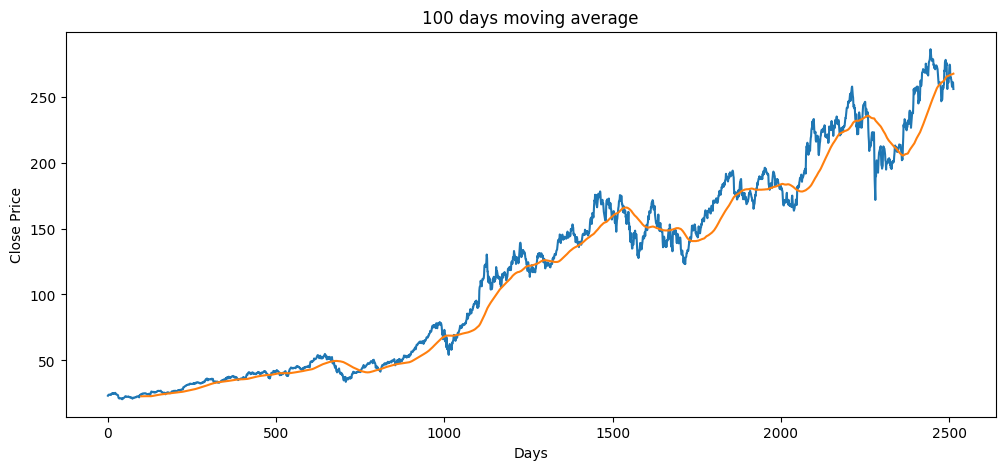

In [20]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'])
plt.title('100 days moving average')
plt.xlabel('Days')
plt.ylabel('Close Price')


## 200 Days moving average

In [21]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(203)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400,NaN,NaN
1,2016-03-15,23.685331,23.821219,23.520000,23.544913,160270800,NaN,NaN
2,2016-03-16,24.000137,24.077140,23.687593,23.692124,153214000,NaN,NaN
3,2016-03-17,23.961628,24.113369,23.771384,23.898212,137682800,NaN,NaN
4,2016-03-18,23.988813,24.120173,23.823484,24.083935,176820800,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2016-12-22,26.778091,26.828751,26.628416,26.791907,104343600,25.599656,NaN
199,2016-12-23,26.831055,26.831055,26.616904,26.616904,56998000,25.626915,24.213419
200,2016-12-27,27.001455,27.125801,26.824146,26.831054,73187600,25.654388,24.232332


Text(0, 0.5, 'Close Price')

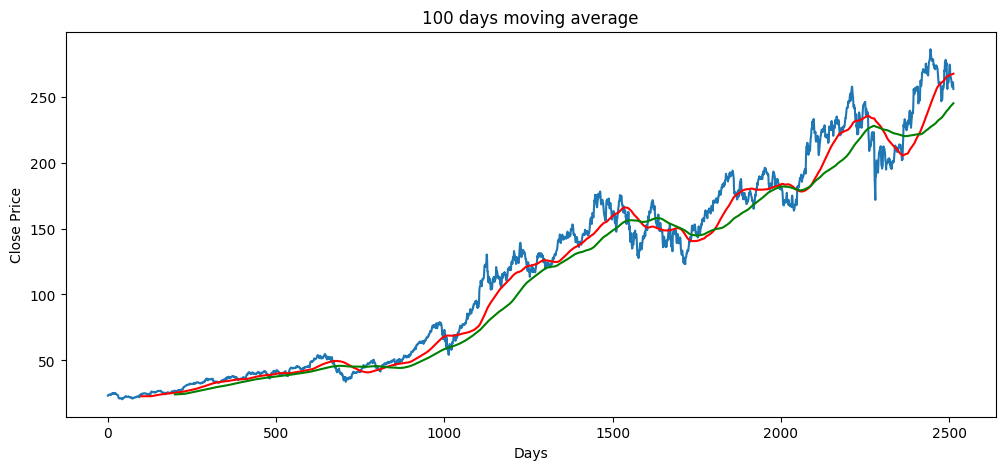

In [22]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'],'r')
plt.plot(df['MA_200'],'g')
plt.title('100 days moving average')
plt.xlabel('Days')
plt.ylabel('Close Price')

In [23]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-03-14,23.218777,23.307106,23.051182,23.080625,100304400,NaN,NaN
1,2016-03-15,23.685331,23.821219,23.520000,23.544913,160270800,NaN,NaN
2,2016-03-16,24.000137,24.077140,23.687593,23.692124,153214000,NaN,NaN
3,2016-03-17,23.961628,24.113369,23.771384,23.898212,137682800,NaN,NaN
4,2016-03-18,23.988813,24.120173,23.823484,24.083935,176820800,NaN,NaN
...,...,...,...,...,...,...,...,...
2509,2026-03-06,257.459991,258.769989,254.369995,258.630005,41120000,266.906516,243.773928
2510,2026-03-09,259.880005,261.149994,253.679993,255.690002,38218500,267.033428,244.042165
2511,2026-03-10,260.829987,262.480011,256.950012,257.649994,30590800,267.168741,244.338931


## Calculating % change in each trading session

In [24]:
df['Percentage Change'] = df.Close.pct_change()
df[['Close','Percentage Change']]

Price,Close,Percentage Change
Ticker,AAPL,
0,23.218777,NaN
1,23.685331,0.020094
2,24.000137,0.013291
3,23.961628,-0.001605
4,23.988813,0.001135
...,...,...
2509,257.459991,-0.010873
2510,259.880005,0.009400
2511,260.829987,0.003655


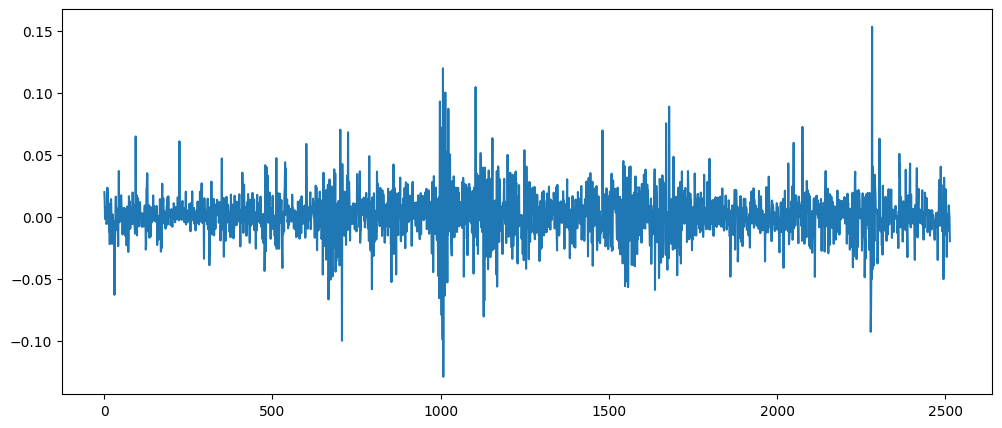

In [25]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage Change'])

## Data Preprocessing

In [26]:
df.shape

(2514, 9)

In [27]:
# Spliting data into traning and testing datasets
data_traning = pd.DataFrame(df.Close[0:int(len(df)*0.7)])

data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])

print(data_traning)
print(data_testing)

Ticker        AAPL
0        23.218777
1        23.685331
2        24.000137
3        23.961628
4        23.988813
...            ...
1754    143.826355
1755    148.873245
1756    151.633270
1757    149.435120
1758    150.686981

[1759 rows x 1 columns]
Ticker        AAPL
1759    148.439560
1760    146.379379
1761    148.321259
1762    150.410980
1763    150.805252
...            ...
2509    257.459991
2510    259.880005
2511    260.829987
2512    260.809998
2513    255.759995

[755 rows x 1 columns]


In [28]:
# Scaling down the data between 0 and 1

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [30]:
data_traning_array = scaler.fit_transform(data_traning)
data_traning_array

array([[0.01672155],
       [0.01968344],
       [0.02168197],
       ...,
       [0.83195409],
       [0.81799925],
       [0.82594663]], shape=(1759, 1))

## Sequence Creation

In [31]:
x_train = []
y_train = []

for i in range(100,data_traning_array.shape[0]):
    x_train.append(data_traning_array[i-100:i])
    y_train.append(data_traning_array[i,0])
x_train,y_train = np.array(x_train),np.array(y_train)

In [32]:
x_train

array([[[0.01672155],
        [0.01968344],
        [0.02168197],
        ...,
        [0.02272531],
        [0.0204543 ],
        [0.02234923]],

       [[0.01968344],
        [0.02168197],
        [0.0214375 ],
        ...,
        [0.0204543 ],
        [0.02234923],
        [0.0232946 ]],

       [[0.02168197],
        [0.0214375 ],
        [0.02161008],
        ...,
        [0.02234923],
        [0.0232946 ],
        [0.02563619]],

       ...,

       [[0.74524446],
        [0.73626194],
        [0.73226955],
        ...,
        [0.77863793],
        [0.78239231],
        [0.81443222]],

       [[0.73626194],
        [0.73226955],
        [0.76127609],
        ...,
        [0.78239231],
        [0.81443222],
        [0.83195409]],

       [[0.73226955],
        [0.76127609],
        [0.73251919],
        ...,
        [0.81443222],
        [0.83195409],
        [0.81799925]]], shape=(1659, 100, 1))

In [33]:
x_train.ndim

3

In [34]:
y_train.ndim

1

In [35]:
x_train.shape

(1659, 100, 1)

In [36]:
y_train.shape

(1659,)

## Model Building

In [37]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [38]:
# Ml model
from keras import Sequential
from keras.layers import Dense,LSTM,Input

In [39]:
model = Sequential()
model.add(Input(shape=(100,1)))
model.add(LSTM(units=128,activation='tanh',return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

## Train Model

In [40]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 19s 250ms/step - loss: 0.0163
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 241ms/step - loss: 7.8226e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 240ms/step - loss: 6.7796e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 242ms/step - loss: 6.6531e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 251ms/step - loss: 6.1103e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 239ms/step - loss: 6.0856e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 239ms/step - loss: 5.9153e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 231ms/step - loss: 7.0679e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 245ms/step - loss: 6.5490e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - loss: 6.3531e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 238ms/step - loss: 4.9961e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 244ms/step - loss: 5.4547e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 233ms/step - loss: 4.8546e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - loss: 4.

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [42]:
# save the train model
#model.save('stock_prediction_model.keras')

## Preparing Test Data

In [43]:
data_testing

Ticker,AAPL
1759,148.439560
1760,146.379379
1761,148.321259
1762,150.410980
1763,150.805252
...,...
2509,257.459991
2510,259.880005
2511,260.829987
2512,260.809998


In [44]:
past_100_days = data_traning.tail(100)
past_100_days

Ticker,AAPL
1659,140.500153
1660,135.970398
1661,139.930206
1662,141.246887
1663,141.354935
...,...
1754,143.826355
1755,148.873245
1756,151.633270
1757,149.435120


In [45]:
final_df = pd.concat([past_100_days,data_testing],ignore_index=True)
final_df

Ticker,AAPL
0,140.500153
1,135.970398
2,139.930206
3,141.246887
4,141.354935
...,...
850,257.459991
851,259.880005
852,260.829987
853,260.809998


In [46]:
input_data = scaler.transform(final_df)
input_data

array([[0.76127609],
       [0.73251919],
       [0.75765782],
       [0.7660167 ],
       [0.76670263],
       [0.76377107],
       [0.78797403],
       [0.80157278],
       [0.81960002],
       [0.80094904],
       [0.77256673],
       [0.84080933],
       [0.82583823],
       [0.80905809],
       [0.77400127],
       [0.73563819],
       [0.73395111],
       [0.73732498],
       [0.74094917],
       [0.71201964],
       [0.78699875],
       [0.80468142],
       [0.79580865],
       [0.80680578],
       [0.79899537],
       [0.81105448],
       [0.81461608],
       [0.79412167],
       [0.80768031],
       [0.8132414 ],
       [0.79474657],
       [0.77044092],
       [0.75138377],
       [0.79424663],
       [0.795996  ],
       [0.79287205],
       [0.78549911],
       [0.76225573],
       [0.74994661],
       [0.76063104],
       [0.75756957],
       [0.7721281 ],
       [0.77825113],
       [0.76413006],
       [0.72220422],
       [0.70977033],
       [0.69639922],
       [0.695

In [47]:
x_test = []
y_test = []
for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [48]:
x_test,y_test = np.array(x_test),np.array(y_test)

In [49]:
x_test

array([[[0.76127609],
        [0.73251919],
        [0.75765782],
        ...,
        [0.83195409],
        [0.81799925],
        [0.82594663]],

       [[0.73251919],
        [0.75765782],
        [0.7660167 ],
        ...,
        [0.81799925],
        [0.82594663],
        [0.81167899]],

       [[0.75765782],
        [0.7660167 ],
        [0.76670263],
        ...,
        [0.82594663],
        [0.81167899],
        [0.79860005]],

       ...,

       [[1.43928061],
        [1.44922864],
        [1.43725294],
        ...,
        [1.52175559],
        [1.50378938],
        [1.5191527 ]],

       [[1.44922864],
        [1.43725294],
        [1.46792089],
        ...,
        [1.50378938],
        [1.5191527 ],
        [1.52518361]],

       [[1.43725294],
        [1.46792089],
        [1.53096789],
        ...,
        [1.5191527 ],
        [1.52518361],
        [1.52505671]]], shape=(755, 100, 1))

In [50]:
y_test

array([0.81167899, 0.79860005, 0.81092796, 0.82419445, 0.82669746,
       0.8445948 , 0.83927569, 0.85429445, 0.86605898, 0.85698539,
       0.86386866, 0.87212921, 0.8598012 , 0.8558589 , 0.87538316,
       0.88533302, 0.90122787, 0.90917515, 0.90579615, 0.89409401,
       0.8997261 , 0.88326796, 0.87557089, 0.87119055, 0.90535801,
       0.90316759, 0.90329304, 0.91105278, 0.9183116 , 0.91217898,
       0.90197871, 0.90391872, 0.89415649, 0.89409401, 0.92319267,
       0.93113995, 0.93057685, 0.92400628, 0.9171852 , 0.9067973 ,
       0.9554827 , 0.95504475, 0.94421899, 0.95542012, 0.95660929,
       0.95071885, 0.9475855 , 0.9475855 , 0.95147075, 0.96625964,
       0.96694896, 0.96093297, 0.94438958, 0.94614418, 0.95335079,
       0.96864098, 0.98035891, 0.98004602, 0.99784233, 1.00323167,
       0.9946465 , 0.99232802, 0.9836178 , 1.00085032, 1.00329424,
       1.02102826, 1.01802046, 1.02203096, 1.0349397 , 1.02810953,
       1.0286734 , 1.02209363, 1.04114362, 1.03913832, 1.03030

## Making Prediction

In [51]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step


In [52]:
y_predicted

array([[0.82790196],
       [0.8188851 ],
       [0.8057257 ],
       [0.80802745],
       [0.81962323],
       [0.8274018 ],
       [0.84142834],
       [0.8439081 ],
       [0.85259724],
       [0.863637  ],
       [0.86177915],
       [0.8636647 ],
       [0.86987555],
       [0.86465555],
       [0.8589533 ],
       [0.8695161 ],
       [0.88195276],
       [0.89717996],
       [0.9078761 ],
       [0.9082968 ],
       [0.89888084],
       [0.8977747 ],
       [0.8874631 ],
       [0.8781548 ],
       [0.8725602 ],
       [0.8938372 ],
       [0.9035217 ],
       [0.9056893 ],
       [0.91010547],
       [0.9160509 ],
       [0.9137555 ],
       [0.90498716],
       [0.9024124 ],
       [0.89592695],
       [0.8936057 ],
       [0.9128396 ],
       [0.9275678 ],
       [0.93167794],
       [0.92688835],
       [0.919081  ],
       [0.9088943 ],
       [0.9377417 ],
       [0.95199543],
       [0.94796175],
       [0.9516183 ],
       [0.9538887 ],
       [0.9503357 ],
       [0.946

In [53]:
y_test

array([0.81167899, 0.79860005, 0.81092796, 0.82419445, 0.82669746,
       0.8445948 , 0.83927569, 0.85429445, 0.86605898, 0.85698539,
       0.86386866, 0.87212921, 0.8598012 , 0.8558589 , 0.87538316,
       0.88533302, 0.90122787, 0.90917515, 0.90579615, 0.89409401,
       0.8997261 , 0.88326796, 0.87557089, 0.87119055, 0.90535801,
       0.90316759, 0.90329304, 0.91105278, 0.9183116 , 0.91217898,
       0.90197871, 0.90391872, 0.89415649, 0.89409401, 0.92319267,
       0.93113995, 0.93057685, 0.92400628, 0.9171852 , 0.9067973 ,
       0.9554827 , 0.95504475, 0.94421899, 0.95542012, 0.95660929,
       0.95071885, 0.9475855 , 0.9475855 , 0.95147075, 0.96625964,
       0.96694896, 0.96093297, 0.94438958, 0.94614418, 0.95335079,
       0.96864098, 0.98035891, 0.98004602, 0.99784233, 1.00323167,
       0.9946465 , 0.99232802, 0.9836178 , 1.00085032, 1.00329424,
       1.02102826, 1.01802046, 1.02203096, 1.0349397 , 1.02810953,
       1.0286734 , 1.02209363, 1.04114362, 1.03913832, 1.03030

In [54]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [55]:
y_predicted

array([150.99498, 149.57466, 147.5018 , 147.86438, 149.69093, 150.9162 ,
       153.12564, 153.51625, 154.88496, 156.62392, 156.33128, 156.6283 ,
       157.60661, 156.78436, 155.88615, 157.54999, 159.509  , 161.90758,
       163.5924 , 163.65869, 162.17549, 162.00125, 160.37698, 158.91075,
       158.0295 , 161.38103, 162.90651, 163.24796, 163.94359, 164.88011,
       164.51852, 163.13734, 162.73178, 161.7102 , 161.34456, 164.37425,
       166.69423, 167.34166, 166.5872 , 165.35739, 163.7528 , 168.2968 ,
       170.54204, 169.90666, 170.48265, 170.84027, 170.2806 , 169.66223,
       169.46896, 169.90387, 171.73387, 172.57657, 172.07846, 169.94806,
       169.23479, 169.93227, 172.00423, 174.12154, 174.74901, 176.62389,
       177.83057, 177.1264 , 176.39117, 175.18744, 176.672  , 177.74652,
       180.03114, 180.51944, 180.87054, 182.30067, 182.03459, 181.81569,
       181.00255, 182.81084, 183.41864, 182.5265 , 184.02301, 185.50519,
       186.16824, 189.2943 , 189.30716, 188.14716, 

(np.float64(-37.7), np.float64(791.7))

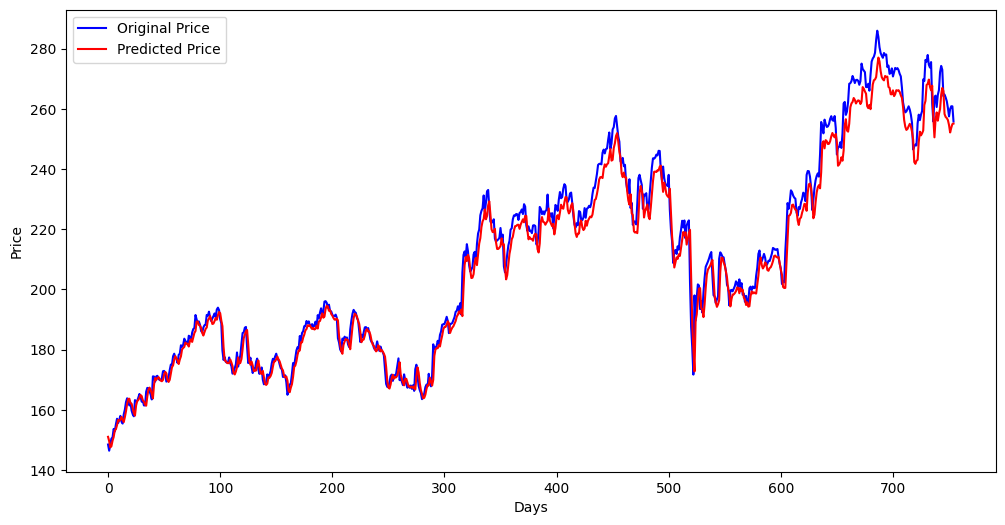

In [57]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Original Price')
plt.plot(y_predicted,'r',label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim()

## Model Evalution

In [66]:
# mean squere error (MSE)
from sklearn.metrics import mean_squared_error,r2_score


In [64]:
mse = mean_squared_error(y_test,y_predicted) 
print(f"Mean squared error (MSE) : {mse}")

Mean squared error (MSE) : 23.468217686902037


In [65]:
# Root mean Squere Error

rmse = np.sqrt(mse)
print(f"Root Mean squared error (RMSE) : {rmse}")

Root Mean squared error (RMSE) : 4.844400653011891


In [68]:
# R-Squared
r2 = r2_score(y_test,y_predicted)
print(f"R-Squred: {r2}")

R-Squred: 0.9792279869295859
